# Exercises lecture 2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/spinjo/ml-lecture-ippp-2026/blob/main/exercises_lecture2.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
# colab has GPUs (=cuda)
# Additional connection options -> Change runtime type -> T4 GPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"device: {device}")

device: cuda


### 1)  QFT amplitude regression

In [3]:
import requests, io
url = "https://raw.githubusercontent.com/spinjo/ml-lecture-ippp-2026/main/zgg_mini.npy"
data = np.load(io.BytesIO(requests.get(url).content))
data = torch.tensor(data).float()

In [4]:
amplitude = data[..., -1]
momenta = data[..., :-1].reshape(data.shape[0], -1, 4)
print(amplitude.shape, momenta.shape)

torch.Size([20000]) torch.Size([20000, 5, 4])


The dataset contains:
- $q\bar q\to Zgg$ amplitude values in `amplitude`
- Momentum values in `momenta` in this order:
  - $(q, \bar q, Z, g, g)$ in `dim=-2`
  - $(E, p_x, p_y, p_z)$ in `dim=-1`

In [5]:
# preprocessing (how to improve this?)
def preprocess_momenta(momenta):
    momenta_reshaped = momenta.reshape(data.shape[0], -1)
    return momenta_reshaped
def preprocess_amplitude(amplitude):
    log_amp = amplitude.log()
    return log_amp
def undo_preprocess_amplitude(prep_amp):  # required for fair evaluation
    amplitude = prep_amp.exp()
    return amplitude

targets = preprocess_amplitude(amplitude)
values = preprocess_momenta(momenta)

torch.testing.assert_close(amplitude, undo_preprocess_amplitude(targets))  # check invertibility
targets = targets.unsqueeze(-1)

In [6]:
# network (how to improve this?)
from torch import nn
class MLP(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels, hidden_layers, dropout_prob=None):
        super().__init__()

        if not hidden_layers > 0:
            raise NotImplementedError("Only supports > 0 hidden layers")

        self.linear_in = nn.Linear(in_channels, hidden_channels)
        
        self.blocks = nn.ModuleList([])
        for _ in range(hidden_layers-1):
            layers = []
            layers.append(nn.GELU())
            layers.append(nn.Linear(hidden_channels, hidden_channels))
            if dropout_prob is not None:
                layers.append(nn.Dropout(dropout_prob))
            block = nn.Sequential(*layers)
            self.blocks.append(block)
            
        self.linear_out = nn.Linear(hidden_channels, out_channels)
        
    def forward(self, inputs):
        embedding = self.linear_in(inputs)
        for block in self.blocks:
            embedding = block(embedding)
        output = self.linear_out(embedding)
        return output
    
network = MLP(in_channels=4*5, out_channels=1, hidden_channels=64, hidden_layers=5)
network = network.to(device)

num_params = sum(p.numel() for p in network.parameters())
print(f"Parameter count: {num_params}")

Parameter count: 18049


In [7]:
# splits, datasets and dataloaders
splits = [14000, 1000, 5000]  # dont change this
targets_train, targets_val , _ = torch.split(targets, splits)
values_train, values_val, _ = torch.split(values, splits)

from torch.utils.data import TensorDataset, DataLoader
data_train = TensorDataset(targets_train, values_train)
data_val = TensorDataset(targets_val, values_val)

batch_size = 128
loader_train = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
loader_val = DataLoader(data_val, batch_size=batch_size)

In [8]:
optim = torch.optim.AdamW(network.parameters(), lr=1e-3)

epochs = 10
losses = []
losses_val = []
for epoch in range(epochs):
    for (target, value) in loader_train:
        target, value = target.to(device), value.to(device)
        prediction = network(value)
        loss = torch.mean((target - prediction)**2)
        
        optim.zero_grad()
        loss.backward()
        optim.step()
        losses.append(loss.item())
        
    val_loss = []
    for (target, value) in loader_val:
        target, value = target.to(device), value.to(device)
        prediction = network(value)
        loss = torch.mean((target - prediction)**2)
        val_loss.append(loss)
    val_loss = torch.stack(val_loss).mean().item()
    losses_val.append(val_loss)
    print(f"Epoch {epoch:>3} loss: {val_loss:.4f}")

Epoch   0 loss: 3.2587
Epoch   1 loss: 2.2545
Epoch   2 loss: 1.7730
Epoch   3 loss: 1.4777
Epoch   4 loss: 1.3653
Epoch   5 loss: 1.6203
Epoch   6 loss: 1.0245
Epoch   7 loss: 1.1015
Epoch   8 loss: 0.9095
Epoch   9 loss: 0.8162


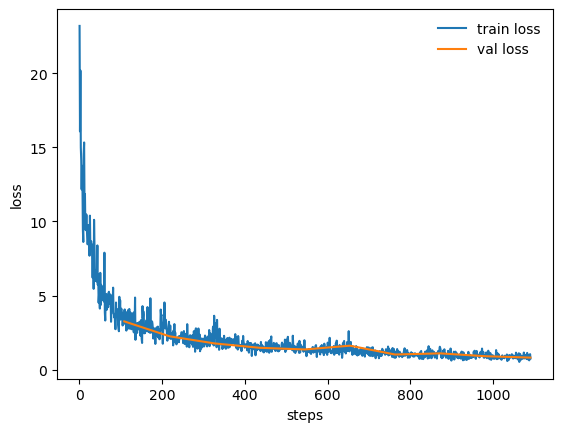

In [9]:
# visualize loss and lr curves
steps_per_epoch = len(loader_train)
steps = torch.arange(steps_per_epoch * epochs) + 1
epochs = torch.arange(epochs) + 1
fig, ax = plt.subplots()
ax.plot(steps, losses, label="train loss")
ax.plot(epochs * steps_per_epoch, losses_val, label="val loss")
ax.set_xlabel("steps")
ax.set_ylabel("loss")

ax.legend(frameon=False)
plt.show()

Test loss: 0.9365


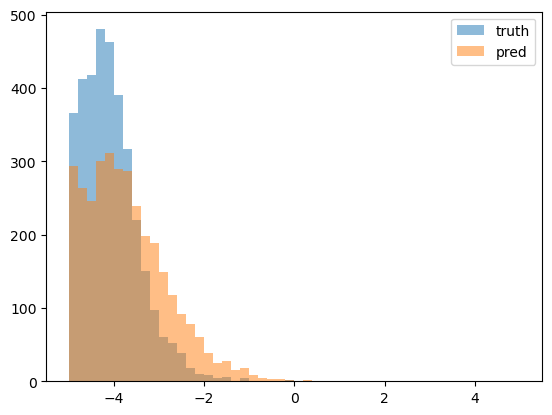

In [10]:
# evaluation (don't touch!)
_, _, targets_test = torch.split(targets, splits)
_, _, values_test = torch.split(values, splits)

targets_test, values_test = targets_test.to(device), values_test.to(device)
prediction = network(values_test).detach()

raw_prediction = undo_preprocess_amplitude(prediction).cpu().squeeze(-1)
raw_truth = undo_preprocess_amplitude(targets_test).cpu().squeeze(-1)

mse_of_log = torch.mean((raw_prediction.log() - raw_truth.log())**2)
print(f"Test loss: {mse_of_log:.4f}")

plt.hist(raw_prediction.log(), range=[-5,5], bins=50, alpha=0.5, label="truth")
plt.hist(raw_truth.log(), range=[-5,5], bins=50, alpha=0.5, label="pred")
plt.legend()
plt.show()